# 🌀 Airflow DAG Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/airflow-dag-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/airflow-dag-gen/demo.ipynb)

**Pain point:** *"Writing DAG boilerplate is repetitive."*

Describe a pipeline in ~30 lines of YAML → get a validated, ready-to-drop-in Airflow DAG. Cycle detection and schema checks run before a single line of code is generated.

**What this notebook covers:**
1. The generator — YAML schema, Jinja template, CI-style validation
2. Generating a 5-task nightly pipeline
3. Validation catching broken configs (cycles, unknown deps, bad types)
4. Drawing the dependency graph
5. Try your own pipeline


## Step 1 — The generator

Three parts:
- **YAML schema** — `dag_id`, `schedule`, `start_date`, defaults, and a `tasks` list where each task has an `id`, a `type` (`bash` | `python` | `sql`), its payload, and optional `depends_on`.
- **Validation first** — duplicate ids, non-identifier ids, unknown task types, missing payloads, unknown dependencies, and dependency cycles (DFS with gray/black coloring) all fail the build *before* code generation, CI-style.
- **Jinja template** — renders operators and `a >> b` edges; imports appear only for operator types actually used.


In [1]:
from __future__ import annotations

from typing import Dict, List, Tuple

import yaml
from jinja2 import Environment

DAG_TEMPLATE = '''"""{{ description }} — generated by airflow-dag-gen, do not edit by hand."""
from datetime import datetime, timedelta

from airflow import DAG
{% if has_bash %}from airflow.operators.bash import BashOperator
{% endif %}{% if has_python %}from airflow.operators.python import PythonOperator
{% endif %}{% if has_sql %}from airflow.providers.common.sql.operators.sql import SQLExecuteQueryOperator
{% endif %}
default_args = {
    "owner": "{{ owner }}",
    "retries": {{ retries }},
    "retry_delay": timedelta(minutes={{ retry_delay_minutes }}),
}

with DAG(
    dag_id="{{ dag_id }}",
    description="{{ description }}",
    schedule="{{ schedule }}",
    start_date=datetime({{ start_date.year }}, {{ start_date.month }}, {{ start_date.day }}),
    catchup={{ catchup }},
    default_args=default_args,
    tags={{ tags }},
) as dag:
{% for task in tasks %}
{% if task.type == "bash" %}    {{ task.id }} = BashOperator(
        task_id="{{ task.id }}",
        bash_command="{{ task.command }}",
    )
{% elif task.type == "python" %}    {{ task.id }} = PythonOperator(
        task_id="{{ task.id }}",
        python_callable={{ task.callable }},
    )
{% elif task.type == "sql" %}    {{ task.id }} = SQLExecuteQueryOperator(
        task_id="{{ task.id }}",
        conn_id="{{ task.conn_id }}",
        sql="""{{ task.sql }}""",
    )
{% endif %}{% endfor %}
{% for edge in edges %}    {{ edge[0] }} >> {{ edge[1] }}
{% endfor %}'''


def validate_config(cfg: Dict) -> List[str]:
    """CI-style validation: structural errors before any code is generated."""
    errors: List[str] = []
    for key in ("dag_id", "schedule", "tasks"):
        if key not in cfg:
            errors.append(f"missing required key: {key}")
    tasks = cfg.get("tasks", [])
    ids = [t.get("id") for t in tasks]
    if len(ids) != len(set(ids)):
        errors.append("duplicate task ids")
    known = set(ids)
    for t in tasks:
        if not t.get("id", "").isidentifier():
            errors.append(f"task id '{t.get('id')}' is not a valid Python identifier")
        ttype = t.get("type")
        if ttype not in ("bash", "python", "sql"):
            errors.append(f"task '{t.get('id')}': unknown type '{ttype}' (bash|python|sql)")
        required = {"bash": "command", "python": "callable", "sql": "sql"}.get(ttype or "", None)
        if required and required not in t:
            errors.append(f"task '{t.get('id')}': type '{ttype}' requires '{required}'")
        for dep in t.get("depends_on", []):
            if dep not in known:
                errors.append(f"task '{t.get('id')}': unknown dependency '{dep}'")
    cycle = _find_cycle(tasks)
    if cycle:
        errors.append(f"dependency cycle: {' -> '.join(cycle)}")
    return errors


def _find_cycle(tasks: List[Dict]) -> List[str]:
    deps = {t["id"]: list(t.get("depends_on", [])) for t in tasks if "id" in t}
    WHITE, GRAY, BLACK = 0, 1, 2
    color = {k: WHITE for k in deps}
    path: List[str] = []

    def visit(node: str) -> List[str]:
        color[node] = GRAY
        path.append(node)
        for dep in deps.get(node, []):
            if color.get(dep) == GRAY:
                return path[path.index(dep):] + [dep]
            if color.get(dep) == WHITE:
                found = visit(dep)
                if found:
                    return found
        color[node] = BLACK
        path.pop()
        return []

    for node in deps:
        if color[node] == WHITE:
            found = visit(node)
            if found:
                return found
    return []


def topo_levels(tasks: List[Dict]) -> Dict[str, int]:
    """Task -> depth level for drawing the DAG left-to-right."""
    deps = {t["id"]: list(t.get("depends_on", [])) for t in tasks}
    levels: Dict[str, int] = {}

    def level(node: str) -> int:
        if node not in levels:
            levels[node] = 1 + max((level(d) for d in deps.get(node, [])), default=-1)
        return levels[node]

    for t in deps:
        level(t)
    return levels


def generate_dag(cfg: Dict) -> Tuple[str, List[str]]:
    """YAML config dict -> (DAG source code, validation errors). Code is '' when errors exist."""
    errors = validate_config(cfg)
    if errors:
        return "", errors
    tasks = cfg["tasks"]
    edges = [(dep, t["id"]) for t in tasks for dep in t.get("depends_on", [])]
    types = {t["type"] for t in tasks}
    start = cfg.get("start_date", "2026-01-01")
    y, m, d = (int(x) for x in str(start).split("-"))

    class _D:
        year, month, day = y, m, d

    code = Environment().from_string(DAG_TEMPLATE).render(
        dag_id=cfg["dag_id"],
        description=cfg.get("description", cfg["dag_id"]),
        schedule=cfg["schedule"],
        owner=cfg.get("owner", "data-eng"),
        retries=cfg.get("retries", 2),
        retry_delay_minutes=cfg.get("retry_delay_minutes", 5),
        catchup=cfg.get("catchup", False),
        tags=cfg.get("tags", ["generated"]),
        start_date=_D,
        tasks=tasks,
        edges=edges,
        has_bash="bash" in types,
        has_python="python" in types,
        has_sql="sql" in types,
    )
    return code, []


def load_yaml(text: str) -> Dict:
    return yaml.safe_load(text)


## Step 2 — A 5-task nightly pipeline

Two parallel extracts fan into a transform, then load, then a dashboard refresh.

In [2]:
CONFIG = """dag_id: nightly_sales_pipeline
description: Extract sales, transform, load to warehouse, refresh dashboard
schedule: "0 2 * * *"
start_date: 2026-07-01
owner: phoebe
retries: 2
tags: [sales, nightly]
tasks:
  - id: extract_orders
    type: bash
    command: python extract.py --source orders
  - id: extract_customers
    type: bash
    command: python extract.py --source customers
  - id: transform
    type: python
    callable: transform_sales
    depends_on: [extract_orders, extract_customers]
  - id: load_warehouse
    type: sql
    conn_id: warehouse
    sql: CALL load_sales_mart();
    depends_on: [transform]
  - id: refresh_dashboard
    type: bash
    command: curl -X POST $DASHBOARD_REFRESH_URL
    depends_on: [load_warehouse]
"""

cfg = load_yaml(CONFIG)
dag_code, errors = generate_dag(cfg)
assert not errors
print(dag_code)

"""Extract sales, transform, load to warehouse, refresh dashboard — generated by airflow-dag-gen, do not edit by hand."""
from datetime import datetime, timedelta

from airflow import DAG
from airflow.operators.bash import BashOperator
from airflow.operators.python import PythonOperator
from airflow.providers.common.sql.operators.sql import SQLExecuteQueryOperator

default_args = {
    "owner": "phoebe",
    "retries": 2,
    "retry_delay": timedelta(minutes=5),
}

with DAG(
    dag_id="nightly_sales_pipeline",
    description="Extract sales, transform, load to warehouse, refresh dashboard",
    schedule="0 2 * * *",
    start_date=datetime(2026, 7, 1),
    catchup=False,
    default_args=default_args,
    tags=['sales', 'nightly'],
) as dag:

    extract_orders = BashOperator(
        task_id="extract_orders",
        bash_command="python extract.py --source orders",
    )

    extract_customers = BashOperator(
        task_id="extract_customers",
        bash_command="python extract.

## Step 3 — Prove the output is valid Python

The generated file must parse — that's the minimum bar for dropping it into `dags/`.

In [3]:
import ast
ast.parse(dag_code)
print(f"✅ {cfg['dag_id']}.py parses cleanly — {len(dag_code.splitlines())} lines from "
      f"{len(CONFIG.splitlines())} lines of YAML")

✅ nightly_sales_pipeline.py parses cleanly — 54 lines from 27 lines of YAML


## Step 4 — Validation catches broken configs

A generator that renders garbage silently is worse than boilerplate. Three sabotaged configs:

In [4]:
broken = {
    "dependency cycle": [{"id": "a", "type": "bash", "command": "x", "depends_on": ["b"]},
                          {"id": "b", "type": "bash", "command": "y", "depends_on": ["a"]}],
    "unknown dependency": [{"id": "a", "type": "bash", "command": "x", "depends_on": ["ghost"]}],
    "bad task type": [{"id": "a", "type": "teleport"}],
}
for name, tasks in broken.items():
    errs = validate_config({"dag_id": "d", "schedule": "@daily", "tasks": tasks})
    print(f"{name}:")
    for e in errs:
        print(f"  ✗ {e}")

dependency cycle:
  ✗ dependency cycle: a -> b -> a
unknown dependency:
  ✗ task 'a': unknown dependency 'ghost'
bad task type:
  ✗ task 'a': unknown type 'teleport' (bash|python|sql)


## Step 5 — Draw the dependency graph

Topological levels position tasks left-to-right — the same view Airflow's UI gives you, before you deploy.

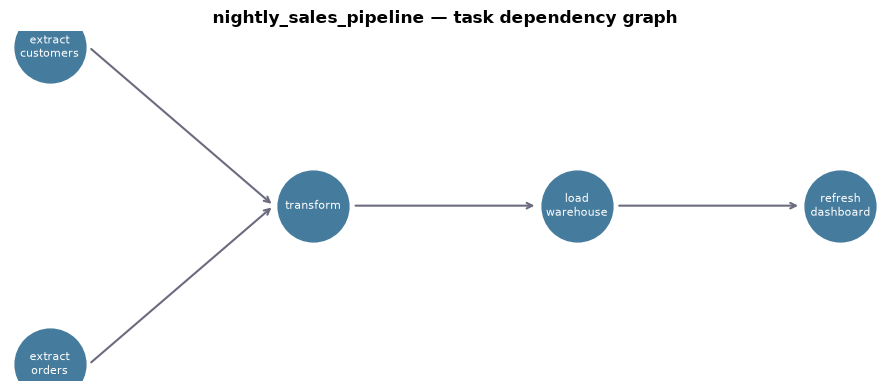

In [5]:
import matplotlib.pyplot as plt

tasks = cfg["tasks"]
levels = topo_levels(tasks)
by_level = {}
for tid, lv in levels.items():
    by_level.setdefault(lv, []).append(tid)
pos = {}
for lv, ids in sorted(by_level.items()):
    for i, tid in enumerate(sorted(ids)):
        pos[tid] = (lv, -(i - (len(ids) - 1) / 2))

fig, ax = plt.subplots(figsize=(9, 4))
for t in tasks:
    for dep in t.get("depends_on", []):
        (x0, y0), (x1, y1) = pos[dep], pos[t["id"]]
        ax.annotate("", xy=(x1 - 0.15, y1), xytext=(x0 + 0.15, y0),
                    arrowprops={"arrowstyle": "->", "color": "#6b6b80", "lw": 1.5})
for tid, (x, y) in pos.items():
    ax.scatter([x], [y], s=2600, color="#457b9d", zorder=3)
    ax.text(x, y, tid.replace("_", "\n"), ha="center", va="center", fontsize=8, color="white", zorder=4)
ax.set_title(f"{cfg['dag_id']} — task dependency graph", fontweight="bold")
ax.axis("off")
fig.tight_layout()
fig.savefig("dag_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Input | Output |
|---|---|
| ~30 lines of YAML | 54 lines of validated DAG code |
| Sabotaged configs | Caught pre-generation: cycles, ghost deps, bad types |
| `depends_on` lists | `a >> b` edges + drawable graph |

The team writes *what* the pipeline does; the generator owns *how* Airflow wants it said. Standardized retries, owners, and tags come free — and nobody hand-writes `PythonOperator` boilerplate again.


## Try your own

In [6]:
# my_yaml = """dag_id: my_pipeline
# schedule: "@hourly"
# start_date: 2026-08-01
# tasks:
#   - id: pull_api
#     type: bash
#     command: python pull.py
#   - id: clean
#     type: python
#     callable: clean_data
#     depends_on: [pull_api]
# """
# c = load_yaml(my_yaml)
# out, errs = generate_dag(c)
# print(out if not errs else errs)

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
